In [54]:
import os, glob, tempfile, shutil
import pandas as pd
import vcfpy
import numpy as np
import pybedtools
import glob
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats as scipy_stats
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
import math
import matplotlib.lines as mlines
import re
from collections import defaultdict
import tempfile, gzip

from variations_analyzer import VariationAnalyzer
from variations_analyzer import SVmethods
from variations_analyzer import SNVmethods
from variations_analyzer import CNVmethods

In [2]:
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm

In [55]:
import importlib
import variations_analyzer
import driver_concordance  

importlib.reload(variations_analyzer)
importlib.reload(driver_concordance)

# re-import classes
from variations_analyzer import VariationAnalyzer
from variations_analyzer import SVmethods
from variations_analyzer import SNVmethods
from variations_analyzer import CNVmethods

In [ ]:
BASE_SAVE_PATH="/path/to/figures"
PLOTSAVEDIR=f"{BASE_SAVE_PATH}/Sonopet_Plots/"

In [36]:
GENE_COORDS = {

    # ── Chromosome 22 ──────────────────────────────────────────────────────────
    "NF2": {
        # 22q12.2  Neurofibromin-2 / Merlin
        "hg38": {"chr": "22", "start": 29_999_545,  "end": 30_094_589},
        "hg19": {"chr": "22", "start": 30_061_987,  "end": 30_157_032},
    },

    # ── Chromosome 16 ──────────────────────────────────────────────────────────
    "TRAF7": {
        # 16p13.3  TNF-receptor associated factor 7
        "hg38": {"chr": "16", "start": 2_336_727,   "end": 2_361_202},
        "hg19": {"chr": "16", "start": 2_286_728,   "end": 2_311_204},
    },

    # ── Chromosome 9 ───────────────────────────────────────────────────────────
    "KLF4": {
        # 9q31.2  Krüppel-like factor 4
        "hg38": {"chr": "9",  "start": 107_552_749, "end": 107_558_277},
        "hg19": {"chr": "9",  "start": 110_247_139, "end": 110_252_667},
    },

    # ── Chromosome 14 ──────────────────────────────────────────────────────────
    "AKT1": {
        # 14q32.33  v-Akt murine thymoma viral oncogene homolog 1
        "hg38": {"chr": "14", "start": 104_769_349, "end": 104_795_751},
        "hg19": {"chr": "14", "start": 105_235_686, "end": 105_262_088},
    },

    # ── Chromosome 7 ───────────────────────────────────────────────────────────
    "SMO": {
        # 7q32.1  Smoothened, frizzled class receptor
        "hg38": {"chr": "7",  "start": 128_831_749, "end": 128_875_540},
        "hg19": {"chr": "7",  "start": 128_836_697, "end": 128_879_947},
    },

    # ── Chromosome 3 ───────────────────────────────────────────────────────────
    "PIK3CA": {
        # 3q26.32  Phosphatidylinositol-4,5-bisphosphate 3-kinase catalytic subunit alpha
        "hg38": {"chr": "3",  "start": 179_148_114, "end": 179_240_085},
        "hg19": {"chr": "3",  "start": 178_865_902, "end": 178_957_881},
    },

    # ── Chromosome 17 ──────────────────────────────────────────────────────────
    "POLR2A": {
        # 17p13.1  RNA polymerase II subunit A
        "hg38": {"chr": "17", "start": 7_484_984,   "end": 7_531_800},
        "hg19": {"chr": "17", "start": 7_590_695,   "end": 7_637_511},
    },
    "TP53": {
        # 17p13.1  Tumor protein p53
        "hg38": {"chr": "17", "start": 7_668_402,   "end": 7_687_538},
        "hg19": {"chr": "17", "start": 7_571_720,   "end": 7_590_868},
    },

    # ── Chromosome 5 ───────────────────────────────────────────────────────────
    # TERT promoter: the recurrent C228T / C250T hotspot mutations lie in the
    # ~300 bp core promoter upstream of the ATG.  We capture the promoter +
    # first exon so vlines land correctly.
    "TERT": {
        # 5p15.33  Telomerase reverse transcriptase  (promoter region included)
        "hg38": {"chr": "5",  "start": 1_253_167,   "end": 1_295_068},
        "hg19": {"chr": "5",  "start": 1_270_656,   "end": 1_312_557},
    },

    # ── Chromosome 9 ───────────────────────────────────────────────────────────
    # CDKN2A and CDKN2B sit next to each other at 9p21.3; they are often
    # co-deleted so it is useful to have both individual loci and a combined one.
    "CDKN2A": {
        # 9p21.3  p16-INK4a / p14-ARF
        "hg38": {"chr": "9",  "start": 21_967_752,  "end": 21_995_324},
        "hg19": {"chr": "9",  "start": 21_967_751,  "end": 21_995_301},
    },
    "CDKN2B": {
        # 9p21.3  p15-INK4b
        "hg38": {"chr": "9",  "start": 22_002_903,  "end": 22_009_371},
        "hg19": {"chr": "9",  "start": 22_002_902,  "end": 22_009_369},
    },
    # Combined locus – useful when you want a single window covering both genes
    "CDKN2A/B": {
        "hg38": {"chr": "9",  "start": 21_967_752,  "end": 22_009_371},
        "hg19": {"chr": "9",  "start": 21_967_751,  "end": 22_009_369},
    },

    # ── Chromosome 3 ───────────────────────────────────────────────────────────
    "BAP1": {
        # 3p21.1  BRCA1-associated protein 1
        "hg38": {"chr": "3",  "start": 52_401_923,  "end": 52_430_819},
        "hg19": {"chr": "3",  "start": 52_435_020,  "end": 52_463_917},
    },

    # ── Chromosome 17 ──────────────────────────────────────────────────────────
    "SMARCE1": {
        # 17q21.2  SWI/SNF related, matrix associated, actin-dependent regulator
        #          of chromatin, subfamily e, member 1
        "hg38": {"chr": "17", "start": 38_617_478,  "end": 38_640_750},
        "hg19": {"chr": "17", "start": 38_549_444,  "end": 38_572_716},
    },

    # ── Chromosome 22 ──────────────────────────────────────────────────────────
    "SMARCB1": {
        # 22q11.23  SWI/SNF related, matrix associated, subfamily b, member 1
        "hg38": {"chr": "22", "start": 23_786_752,  "end": 23_819_280},
        "hg19": {"chr": "22", "start": 24_129_183,  "end": 24_176_705},
    },

    # ── Chromosome 10 ──────────────────────────────────────────────────────────
    "PTEN": {
        # 10q23.31  Phosphatase and tensin homolog
        "hg38": {"chr": "10", "start": 87_863_113,  "end": 87_971_930},
        "hg19": {"chr": "10", "start": 89_622_870,  "end": 89_731_687},
    },

    # ── EGFR (kept from the original function for convenience) ─────────────────
    "EGFR": {
        # 7p11.2  Epidermal growth factor receptor
        "hg38": {"chr": "7",  "start": 55_018_820,  "end": 55_211_628},
        "hg19": {"chr": "7",  "start": 55_086_710,  "end": 55_279_321},
    },
}

In [38]:
MENINGIOMA_GENES = [
    "NF2", "TRAF7", "KLF4", "AKT1", "SMO", "PIK3CA",
    "POLR2A", "TERT", "CDKN2A/B", "BAP1", "SMARCE1",
    "SMARCB1", "PTEN", "TP53", "EGFR"
]

In [5]:
# Parse BND ALT field to get remote mate (chrom, pos)
_BND_MATE_RE = re.compile(r'[\[\]](?P<chrom>[^:\[\]]+):(?P<pos>\d+)[\[\]]')

PRIMARY_CHROMS = {str(i) for i in range(1, 23)} | {"X", "Y", "MT"}

In [6]:
PRIMARY_ORDER = [str(i) for i in range(1,23)] + ["X","Y","MT"]

In [7]:
SEQID_TO_SR = {
    1:  "1S",  2:  "1R",
    3:  "2S",            # patient 2 – no resection, skip pairing
    4:  "3R",  5:  "3S",
    6:  "4R",  7:  "4S",
    8:  "5R",  9:  "5S",
    10: "6R",  11: "6S",
    12: "7R",  13: "7S",
    14: "8R",  15: "8S",
}

from collections import defaultdict

patient_pairs = defaultdict(dict)

for seqid, sr in SEQID_TO_SR.items():
    patient = int(sr[:-1])
    status = sr[-1]  # S or R
    patient_pairs[patient][status] = seqid

# keep only complete pairs
patient_pairs = {
    p: v for p, v in patient_pairs.items()
    if "S" in v and "R" in v
}

## NanoStats

In [10]:
def summarise_nanostats_bar(
    nanostats_dir,
    seqid_to_sr   = SEQID_TO_SR,
    skip_patients = ("2",),
    output_csv    = "nanostats_summary.csv",
    save_path=None
):
    import re
    from pathlib import Path
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    from collections import defaultdict

    nanostats_dir = Path(nanostats_dir)

    def _seqid_of(name):
        m = re.search(r"ONTWGS[^-]*-(\d+)-", str(name))
        return int(m.group(1)) if m else None

    def _parse_value(line):
        return float(line.split(":")[-1].replace(",", "").strip())

    # ── parse files ───────────────────────────────────────────────────────────
    seqid_to_stats = {}
    for fpath in nanostats_dir.iterdir():
        if not fpath.is_file():
            continue
        sid = _seqid_of(fpath.name)
        if sid is None:
            continue
        total_bases = total_aligned = None
        with open(fpath) as f:
            for line in f:
                if line.strip().startswith("Total bases:"):
                    total_bases = _parse_value(line)
                elif line.strip().startswith("Total bases aligned:"):
                    total_aligned = _parse_value(line)
        if total_bases is not None and total_aligned is not None:
            seqid_to_stats[sid] = {
                "total_bases":   total_bases,
                "total_aligned": total_aligned,
            }
        else:
            print(f"  [WARN] Could not parse {fpath.name}")

    # ── patient pairs ─────────────────────────────────────────────────────────
    buckets = defaultdict(dict)
    for seqid, label in seqid_to_sr.items():
        patient, sr = label[:-1], label[-1]
        buckets[patient][sr] = seqid

    rows = []
    for patient in sorted(buckets, key=lambda x: int(x)):
        if patient in skip_patients:
            continue
        b = buckets[patient]
        for sr_label, sr_key in [("R", "R"), ("S", "S")]:
            if sr_key not in b:
                continue
            seqid = b[sr_key]
            stats = seqid_to_stats.get(seqid, {})
            rows.append({
                "patient":       patient,
                "sample_type":   sr_label,
                "seqid":         seqid,
                "total_bases":   stats.get("total_bases"),
                "total_aligned": stats.get("total_aligned"),
                "pct_aligned":   (
                    100 * stats["total_aligned"] / stats["total_bases"]
                    if stats.get("total_bases") else None
                ),
            })

    df = pd.DataFrame(rows).sort_values(["patient", "sample_type"])
    df.to_csv(output_csv, index=False)
    print(f"Saved: {output_csv}")
    display(df)

    # ── bar plot helper ───────────────────────────────────────────────────────
    patients  = df["patient"].unique()
    x         = range(len(patients))
    bar_width = 0.35
    colors    = {"R": "tab:red", "S": "tab:blue"}

    def _gb(v, _):
        return f"{v/1e9:.0f} Gb"

    for col, title in [("total_bases", "Total Bases"),
                        ("total_aligned", "Total Bases Aligned")]:
        fig, ax = plt.subplots(figsize=(10, 4))

        r_vals = [
            df[(df["patient"] == p) & (df["sample_type"] == "R")][col].values[0]
            if not df[(df["patient"] == p) & (df["sample_type"] == "R")].empty else 0
            for p in patients
        ]
        s_vals = [
            df[(df["patient"] == p) & (df["sample_type"] == "S")][col].values[0]
            if not df[(df["patient"] == p) & (df["sample_type"] == "S")].empty else 0
            for p in patients
        ]

        ax.bar([i - bar_width/2 for i in x], r_vals, width=bar_width,
               color=colors["R"], alpha=0.8, label="Resection")
        ax.bar([i + bar_width/2 for i in x], s_vals, width=bar_width,
               color=colors["S"], alpha=0.8, label="Sonopet")

        ax.set_xticks(list(x))
        ax.set_xticklabels([f"P{p}" for p in patients], fontsize=9)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(_gb))
        ax.set_ylabel("Sequencing yield (Gb)", fontsize=10)
        ax.set_title(title, fontsize=11)
        ax.legend(frameon=False, fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", linestyle=":", alpha=0.4)

        plt.tight_layout()
        plt.show()

    # ── combined overlay plot ─────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 4))

    r_total   = [df[(df["patient"]==p)&(df["sample_type"]=="R")]["total_bases"].values[0]
                if not df[(df["patient"]==p)&(df["sample_type"]=="R")].empty else 0 for p in patients]
    s_total   = [df[(df["patient"]==p)&(df["sample_type"]=="S")]["total_bases"].values[0]
                if not df[(df["patient"]==p)&(df["sample_type"]=="S")].empty else 0 for p in patients]
    r_aligned = [df[(df["patient"]==p)&(df["sample_type"]=="R")]["total_aligned"].values[0]
                if not df[(df["patient"]==p)&(df["sample_type"]=="R")].empty else 0 for p in patients]
    s_aligned = [df[(df["patient"]==p)&(df["sample_type"]=="S")]["total_aligned"].values[0]
                if not df[(df["patient"]==p)&(df["sample_type"]=="S")].empty else 0 for p in patients]

    # solid filled bars — total aligned
    ax.bar([i - bar_width/2 for i in x], r_aligned, width=bar_width,
        color=colors["R"], alpha=0.8, label="Resection (aligned)")
    ax.bar([i + bar_width/2 for i in x], s_aligned, width=bar_width,
        color=colors["S"], alpha=0.8, label="Sonopet (aligned)")

    # hatched outline bars — total bases (drawn on top, same origin)
    ax.bar([i - bar_width/2 for i in x], r_total, width=bar_width,
        color="none", edgecolor=colors["R"], linewidth=1.5,
        linestyle="--", hatch="///", label="Resection (total)")
    ax.bar([i + bar_width/2 for i in x], s_total, width=bar_width,
        color="none", edgecolor=colors["S"], linewidth=1.5,
        linestyle="--", hatch="///", label="Sonopet (total)")

    ax.set_xticks(list(x))
    ax.set_xticklabels([f"P{p}" for p in patients], fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(_gb))
    ax.set_ylabel("Sequencing yield (Gb)", fontsize=10)
    ax.set_title("Total Bases vs Aligned", fontsize=11)
    ax.legend(frameon=False, fontsize=9, ncol=2)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle=":", alpha=0.4)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, 
                    format="pdf", 
                    # format="png", dpi=300, 
                    bbox_inches="tight")
    plt.show()

    return df

Saved: /path/to/data/ONTWGS9_NanoStats/nanostats_summary.csv


,patient,sample_type,seqid,total_bases,total_aligned,pct_aligned
0,1,R,2,1.111478e+11,1.032718e+11,92.913986
1,1,S,1,1.238088e+11,1.164340e+11,94.043390
2,3,R,4,8.997238e+10,8.408140e+10,93.452456
3,3,S,5,1.113694e+11,1.036533e+11,93.071659
4,4,R,6,1.325016e+11,1.215943e+11,91.768158
5,4,S,7,9.482896e+10,8.727332e+10,92.032357
6,5,R,8,1.040242e+11,9.759273e+10,93.817372
7,5,S,9,9.791828e+10,9.048041e+10,92.404005
8,6,R,10,1.238089e+11,1.151121e+11,92.975580
9,6,S,11,1.129552e+11,1.071951e+11,94.900496


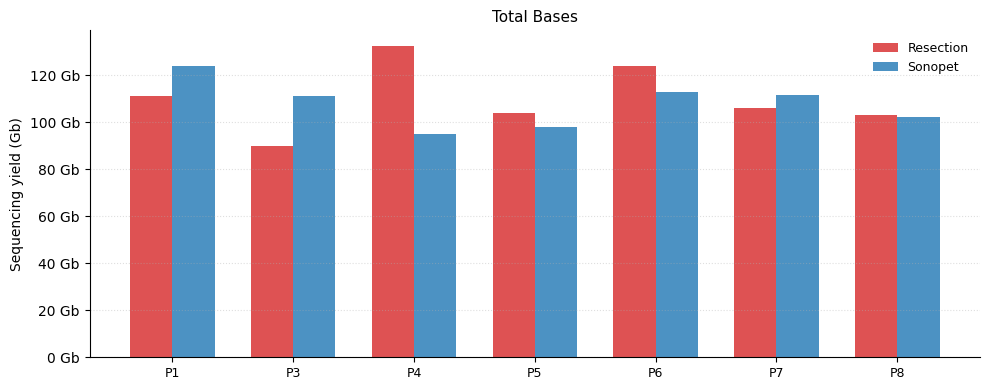

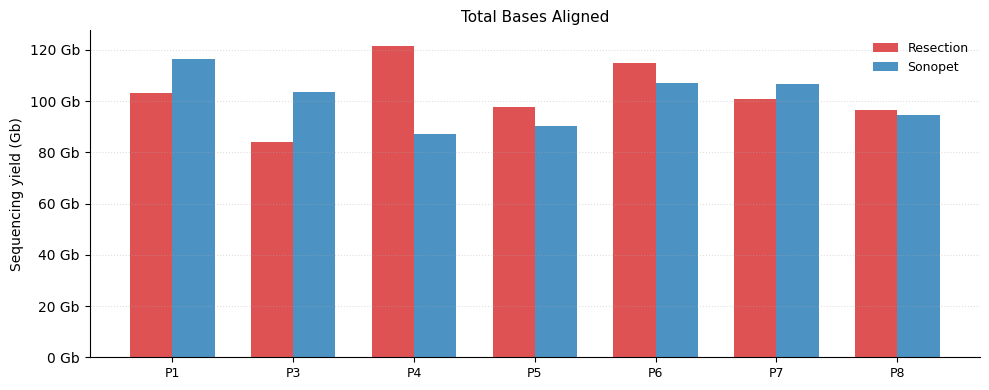

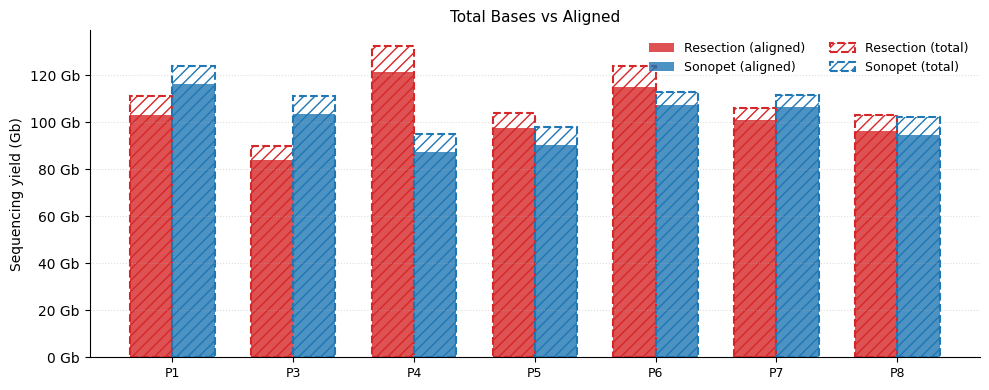

In [11]:
df_nano = summarise_nanostats_bar(
    nanostats_dir = "/path/to/data/ONTWGS9_NanoStats",
    output_csv    = "/path/to/data/ONTWGS9_NanoStats/nanostats_summary.csv",
    save_path="/path/to/figures/sequence_yields.pdf"
)

## Clair SNV results

In [12]:
SAMPLEGROUP = 'ONTWGS9'

CLAIRSTO_ROOT = f"/path/to/data/clair/output_clairs-to/{SAMPLEGROUP}"

samples_clairsto = VariationAnalyzer.discover_samples(CLAIRSTO_ROOT)

SAMPLES = sorted(
    samples_clairsto
)

print(f"Discovered {len(SAMPLES)} samples")

Discovered 15 samples


In [13]:
clairsto_all_raw = SNVmethods.load_caller_vcfs(
    samples=SAMPLES,
    caller="clairs_to",
    root=CLAIRSTO_ROOT,
)

Not including ClairS-TO INDELs
Not including ClairS-TO INDELs
Not including ClairS-TO INDELs
Not including ClairS-TO INDELs
Not including ClairS-TO INDELs
Not including ClairS-TO INDELs
Not including ClairS-TO INDELs
Not including ClairS-TO INDELs
Not including ClairS-TO INDELs
Not including ClairS-TO INDELs
Not including ClairS-TO INDELs
Not including ClairS-TO INDELs
Not including ClairS-TO INDELs
Not including ClairS-TO INDELs
Not including ClairS-TO INDELs


#### VAF distributions for ClairS-TO categories

In [14]:
from scipy.stats import spearmanr

def compute_vaf_correlation(
    df: pd.DataFrame,
    seqid_to_sr: dict,
    patient_pairs: dict,
    min_depth: int = 20,
    pass_only: bool = True,
) -> pd.DataFrame:
    """
    Compute per-patient Spearman correlation of VAFs at shared variant sites
    between matched R and S samples.

    Parameters
    ----------
    df : pd.DataFrame
        Raw SNV dataframe with columns: sample, chrom, pos, ref, alt, filter, vaf, dp
    seqid_to_sr : dict
        Mapping from integer seqid to patient-method string e.g. {1: '1S', 2: '1R', ...}
    patient_pairs : dict
        Mapping from patient int to {'R': seqid, 'S': seqid} for complete pairs only
    min_depth : int
        Minimum read depth filter (default: 20)
    pass_only : bool
        Whether to restrict to PASS variants only (default: True)

    Returns
    -------
    pd.DataFrame
        Per-patient table with columns: patient, n_shared, spearman_rho, p
    """
    df = df.copy()

    # Parse sample name to get seqid, patient, method
    df['seqid'] = df['sample'].apply(lambda x: int(x.split('-')[1]))
    df['sr'] = df['seqid'].map(seqid_to_sr)
    df['patient'] = df['sr'].str[:-1].astype(int)
    df['method'] = df['sr'].str[-1]

    # Apply filters
    mask = df['dp'] >= min_depth
    if pass_only:
        mask &= df['filter'] == 'PASS'
    filtered = df[mask]

    results = []
    for patient, ids in patient_pairs.items():
        r_df = filtered[
            (filtered['patient'] == patient) &
            (filtered['method'] == 'R')
        ][['chrom', 'pos', 'ref', 'alt', 'vaf']].rename(columns={'vaf': 'vaf_R'})

        s_df = filtered[
            (filtered['patient'] == patient) &
            (filtered['method'] == 'S')
        ][['chrom', 'pos', 'ref', 'alt', 'vaf']].rename(columns={'vaf': 'vaf_S'})

        merged = r_df.merge(s_df, on=['chrom', 'pos', 'ref', 'alt'])

        if len(merged) > 10:
            rho, pval = spearmanr(merged['vaf_R'], merged['vaf_S'])
            results.append({
                'patient': patient,
                'n_shared': len(merged),
                'spearman_rho': round(rho, 3),
                'p': round(pval, 4)
            })

    return pd.DataFrame(results).sort_values('patient').reset_index(drop=True)

In [15]:
results_df = compute_vaf_correlation(
    df=clairsto_all_raw,
    seqid_to_sr=SEQID_TO_SR,
    patient_pairs=patient_pairs,
    min_depth=20,
    pass_only=True,
)
print(results_df)

   patient  n_shared  spearman_rho    p
0        1     19184         0.188  0.0
1        3      6908         0.165  0.0
2        4     29492         0.051  0.0
3        5     16476         0.107  0.0
4        6     12884         0.166  0.0
5        7     16038         0.246  0.0
6        8     18925         0.167  0.0


#### VAF Filter

In [16]:
clairsto_all = SNVmethods.filter_snv_by_vaf(clairsto_all_raw, min_vaf=0.1, max_vaf=0.6)

In [17]:
results_df = compute_vaf_correlation(
    df=clairsto_all,
    seqid_to_sr=SEQID_TO_SR,
    patient_pairs=patient_pairs,
    min_depth=20,
    pass_only=True,
)
print(results_df)

   patient  n_shared  spearman_rho    p
0        1     16852         0.188  0.0
1        3      5477         0.186  0.0
2        4     21996         0.052  0.0
3        5     12115         0.116  0.0
4        6     10242         0.183  0.0
5        7     11780         0.144  0.0
6        8     14943         0.174  0.0


In [18]:
def plot_vaf_per_sample(
    clairs_df,
    seqid_to_sr   = SEQID_TO_SR,
    skip_patients = ("2",),
    sample_col    = "sample",
    vaf_col       = "vaf",
    figsize       = (10, 5),
    style         = "box",       # "box" or "violin"
    save_path     = None
):

    def _seqid_of(name):
        m = re.search(r"ONTWGS[^-]*-(\d+)-", str(name))
        return int(m.group(1)) if m else None

    df = clairs_df.copy()
    df["_seqid"] = df[sample_col].map(_seqid_of)
    df = df.dropna(subset=[vaf_col, "_seqid"])
    df["_seqid"] = df["_seqid"].astype(int)

    buckets = defaultdict(dict)
    for seqid, label in seqid_to_sr.items():
        patient, sr = label[:-1], label[-1]
        buckets[patient][sr] = seqid

    pairs = []
    for patient in sorted(buckets, key=lambda x: int(x)):
        if patient in skip_patients:
            continue
        b = buckets[patient]
        slots = []
        if "R" in b: slots.append((b["R"], "Resection"))
        if "S" in b: slots.append((b["S"], "Sonopet"))
        if slots:
            pairs.append((patient, slots))

    fig, ax = plt.subplots(figsize=figsize)

    box_width   = 0.35
    slot_gap    = 0.5
    patient_gap = 0.3

    xtick_pos    = []
    xtick_labels = []
    patient_mids = []
    colors = {"Sonopet": "tab:blue", "Resection": "tab:red"}

    x = 0.0
    for patient, slots in pairs:
        slot_positions = []
        for seqid, sr_label in slots:
            vals = df.loc[df["_seqid"] == seqid, vaf_col].values
            color = colors[sr_label]
            if len(vals) > 0:
                if style == "violin":
                    parts = ax.violinplot(
                        vals,
                        positions  = [x],
                        widths     = box_width * 2,
                        showmedians= True,
                        showextrema= False,
                    )
                    for pc in parts["bodies"]:
                        pc.set_facecolor(color)
                        pc.set_alpha(0.75)
                    parts["cmedians"].set_color("black")
                    parts["cmedians"].set_linewidth(1.5)
                else:
                    ax.boxplot(
                        vals,
                        positions    = [x],
                        widths       = box_width,
                        patch_artist = True,
                        showfliers   = False,
                        manage_ticks = False,
                        boxprops     = dict(facecolor=color, alpha=0.75),
                        medianprops  = dict(color="black", linewidth=1.5),
                        whiskerprops = dict(color=color, linewidth=1),
                        capprops     = dict(color=color, linewidth=1),
                    )

            xtick_pos.append(x)
            xtick_labels.append(sr_label[0])
            slot_positions.append(x)
            x += slot_gap

        patient_mids.append((np.mean(slot_positions), f"P{patient}"))
        x += patient_gap

    ax.set_xticks(xtick_pos)
    ax.set_xticklabels(xtick_labels, fontsize=15)
    ax.set_xlim(-0.5, x - patient_gap)
    ax.set_ylim(0, 1)
    ax.set_ylabel("VAF", fontsize=20)
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", length=0)

    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks([pos for pos, _ in patient_mids])
    ax2.set_xticklabels([lbl for _, lbl in patient_mids], fontsize=15, fontweight="bold")
    ax2.tick_params(axis="x", length=0)
    ax2.spines[["top", "right", "left", "bottom"]].set_visible(False)

    for i in range(1, len(patient_mids)):
        sep = (patient_mids[i-1][0] + patient_mids[i][0]) / 2
        ax.axvline(sep, color="lightgrey", linestyle="--", linewidth=0.8)

    ax.legend(
        handles=[
            mpatches.Patch(facecolor="tab:red",  alpha=0.75, label="Resection"),
            mpatches.Patch(facecolor="tab:blue", alpha=0.75, label="Sonopet"),
        ],
        frameon=False, fontsize=12,
        loc="upper right",
    )

    ax.set_title("VAF distribution per sample", fontsize=20, pad=20)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, format="pdf", bbox_inches="tight")
    plt.show()

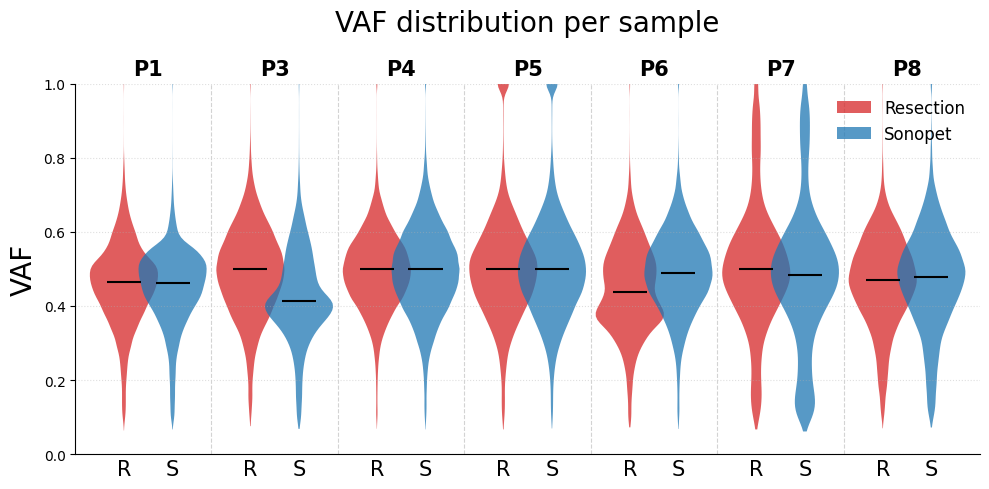

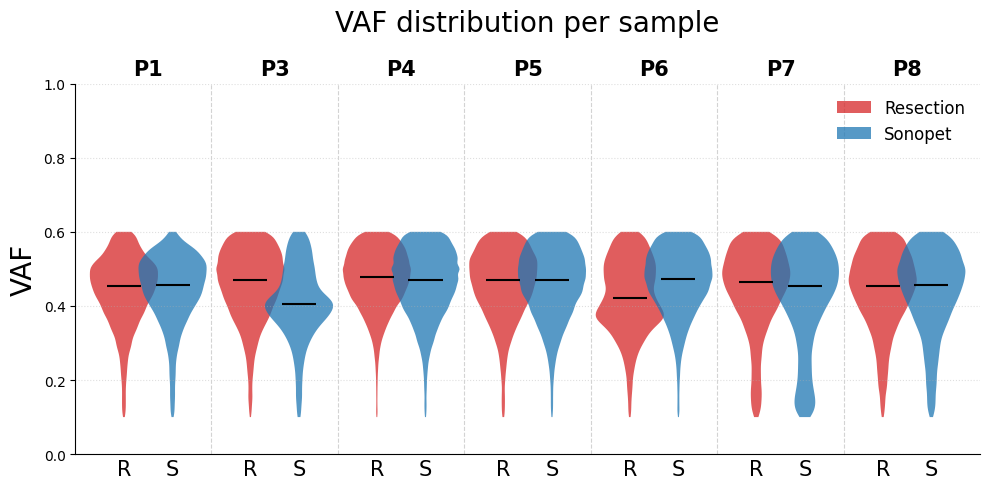

In [19]:
# pass whichever you have — raw or VAF-filtered, doesn't matter
plot_vaf_per_sample(clairsto_all_raw,
                    style = "violin",
                    save_path="/path/to/figures/vaf_unfiltered.pdf"
                    )
# or
plot_vaf_per_sample(clairsto_all,
                    style = "violin",
                    save_path="/path/to/figures/vaf_filtered.pdf"
                    )

### SNV per chromsome

In [ ]:
chrom_order = [str(i) for i in range(1, 23)] + ["X", "Y"]
counts_clairs = SNVmethods.build_chr_sample_count_matrix(clairsto_all, chrom_order)

# intersect samples if there are more than 1 SNV caller
# this will find a joint subset of all the tools' results
common_samples = sorted(
    set(counts_clairs.columns) 
    # & set(counts_<another caller>.columns)
)
def sample_sort_key(sample_name):
    """
    Extract the numeric sample index from:
    ONTWGS#-<index>-<6digit>-<tag>
    """
    for part in sample_name.split("-"):
        if part.isdigit():
            return int(part)
    return float("inf")

common_samples = sorted(common_samples, key=sample_sort_key)

# subset matrices
counts_clairs = counts_clairs[common_samples]

## CNVKIT

How We Convert log2 to Percent Genome Amplified

We are NOT converting log2 directly to percent.

We are doing this:

Step 1 — Compute segment length
length=end−start
length=end−start

Step 2 — Select segments above threshold

Example threshold:

log2≥0.5
log2≥0.5

That selects all regions with ~3+ copies.

Step 3 — Sum their genomic length
amplified length=∑(length of segments meeting threshold)
amplified length=∑(length of segments meeting threshold)
Step 4 — Divide by total genome covered
percent amplified=amplified lengthtotal segment length×100
percent amplified=
total segment length
amplified length
	​

×100

In [24]:
def get_patient_colors(df):
    patients = sorted(df["patient"].unique())
    cmap = plt.get_cmap("tab10")
    return {
        patient: cmap(i % cmap.N)
        for i, patient in enumerate(patients)
    }

In [25]:
def calculate_amplification_percentage(
    cns_file,
    log2_threshold=0.5,
    exclude_sex=False,
    reference_genome_size=None,
    return_dataframe=False
):
    """
    Calculate percentage of genome amplified from CNVkit .cns file.

    Parameters
    ----------
    cns_file : str
        Path to CNVkit .cns file
    log2_threshold : float
        log2 copy ratio threshold for amplification
    exclude_sex : bool
        Whether to exclude chrX/chrY
    reference_genome_size : int or None
        If provided, percentage is normalized to this genome size
        instead of covered segment length
    return_dataframe : bool
        If True, also return the loaded dataframe

    Returns
    -------
    dict
        Summary statistics
    """

    import pandas as pd

    df = pd.read_csv(cns_file, sep="\t")

    required_cols = {"chromosome", "start", "end", "log2"}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"Input file must contain columns: {required_cols}")

    # Optional: remove sex chromosomes
    if exclude_sex:
        df = df[~df["chromosome"].isin(["chrX", "chrY", "X", "Y"])]

    # Segment length
    df["length"] = df["end"] - df["start"]

    covered_length = df["length"].sum()

    # Amplified segments
    amplified_df = df[df["log2"] >= log2_threshold]
    amplified_length = amplified_df["length"].sum()

    # Choose denominator
    if reference_genome_size is not None:
        total_length = reference_genome_size
    else:
        total_length = covered_length

    percent_amplified = (amplified_length / total_length) * 100

    results = {
        "total_length_used": total_length,
        "covered_length": covered_length,
        "amplified_length": amplified_length,
        "percent_amplified": percent_amplified,
        "threshold_used": log2_threshold,
    }

    if return_dataframe:
        return results, df

    return results

def calculate_cnv_burden(
    cns_file,
    gain_threshold=0.5,
    loss_threshold=-0.5,
    exclude_sex=False,
):
    import pandas as pd
    
    df = pd.read_csv(cns_file, sep="\t")
    
    if exclude_sex:
        df = df[~df["chromosome"].isin(["chrX", "chrY", "X", "Y"])]
    
    df["length"] = df["end"] - df["start"]
    total_length = df["length"].sum()
    
    gain_length = df.loc[df["log2"] >= gain_threshold, "length"].sum()
    loss_length = df.loc[df["log2"] <= loss_threshold, "length"].sum()
    
    gain_percent = gain_length / total_length * 100
    loss_percent = loss_length / total_length * 100
    fga_percent = (gain_length + loss_length) / total_length * 100
    
    return {
        "gain_percent": gain_percent,
        "loss_percent": loss_percent,
        "FGA_percent": fga_percent,
        "total_length": total_length
    }

In [26]:
def extract_seqid_cnvkit(folder_name):
    base_name = folder_name.replace("_cnvkit", "")
    return int(base_name.split("-")[1])

In [27]:
BASE_PATH = f"/path/to/data/cnvkit/{SAMPLEGROUP}"

sample_dirs = [
    d for d in os.listdir(BASE_PATH)
    if os.path.isdir(os.path.join(BASE_PATH, d))
]

seqid_to_folder = {}

for folder in sample_dirs:
    try:
        seqid = extract_seqid_cnvkit(folder)
        seqid_to_folder[seqid] = folder
    except Exception:
        continue

seqid_to_folder

{8: 'ONTWGS9-8-240186-NP01_cnvkit',
 10: 'ONTWGS9-10-240188-NP01_cnvkit',
 13: 'ONTWGS9-13-240191-NP01_cnvkit',
 5: 'ONTWGS9-5-240183-NP01_cnvkit',
 3: 'ONTWGS9-3-238703-NP01_cnvkit',
 1: 'ONTWGS9-1-238701-NP01_cnvkit',
 9: 'ONTWGS9-9-240187-NP01_cnvkit',
 12: 'ONTWGS9-12-240190-NP01_cnvkit',
 11: 'ONTWGS9-11-240189-NP01_cnvkit',
 4: 'ONTWGS9-4-240182-NP01_cnvkit',
 2: 'ONTWGS9-2-238702-NP01_cnvkit',
 15: 'ONTWGS9-15-240193-NP01_cnvkit',
 7: 'ONTWGS9-7-240185-NP01_cnvkit',
 6: 'ONTWGS9-6-240184-NP01_cnvkit',
 14: 'ONTWGS9-14-240192-NP01_cnvkit'}

In [71]:
results = []

for patient, pair in patient_pairs.items():
    
    seqid_s = pair["S"]
    seqid_r = pair["R"]
    
    # Ensure both S and R exist
    if seqid_s not in seqid_to_folder or seqid_r not in seqid_to_folder:
        print(f"Skipping patient {patient} (missing folder)")
        continue
    
    folder_s = seqid_to_folder[seqid_s]
    folder_r = seqid_to_folder[seqid_r]
    
    sample_s = folder_s.replace("_cnvkit", "")
    sample_r = folder_r.replace("_cnvkit", "")
    
    file_s = os.path.join(BASE_PATH, folder_s, f"{sample_s}.sorted.cns")
    file_r = os.path.join(BASE_PATH, folder_r, f"{sample_r}.sorted.cns")
    
    if not os.path.exists(file_s) or not os.path.exists(file_r):
        print(f"Skipping patient {patient} (missing .sorted.cns)")
        continue
    
    # Compute gain/loss burden
    res_s = calculate_cnv_burden(file_s)
    res_r = calculate_cnv_burden(file_r)
    
    results.append({
        "patient": patient,
        "S_gain": res_s["gain_percent"],
        "S_loss": res_s["loss_percent"],
        "R_gain": res_r["gain_percent"],
        "R_loss": res_r["loss_percent"],
    })

df_sr = pd.DataFrame(results).sort_values("patient").reset_index(drop=True)

df_sr

,patient,S_gain,S_loss,R_gain,R_loss
0,1,0.057058,6.563507,0.088087,4.146805
1,3,0.066477,2.113677,0.067970,1.806553
2,4,0.059578,1.522133,0.061534,1.518959
3,5,0.101837,5.900409,0.069349,5.829051
4,6,0.028218,1.503979,0.032120,1.845099
5,7,0.083902,23.000021,0.067432,23.848165
6,8,0.069646,13.323676,0.105029,15.336254


In [81]:
# ── Shared plot config ─────────────────────────────────────────────────────────
PLOT_CFG = dict(
    figsize          = (6, 6),
    scatter_s        = 200,
    diagonal_kw      = dict(linestyle="--", color="gray"),
    legend_kw = dict(frameon=True, framealpha=0.7, facecolor="white"),
    fontsize_title   = 20,
    fontsize_label   = 19,
    fontsize_tick    = 15,
    fontsize_legend  = 15,
    corr_fontsize    = 15,
    corr_bbox_kw     = dict(boxstyle="round,pad=0.3", facecolor="white",
                            edgecolor="lightgrey", alpha=0.8),
    show_ci          = True,       # Show bootstrap CIs
    ci_level         = 0.95,
    ci_n_boot        = 5000,
    ci_seed          = 0,
    exact_p          = True,        # exact permutation p for small n (falls back if n>8)
    exclude_patients = (),      # subset line excludes these; set to () to drop the 2nd line
)

def _save_fig(fig, path, fmt="pdf"):
    """Save fig to path, appending the correct extension."""
    if path is None:
        return
    ext_map = {"pdf": ".pdf", "png": ".png"}
    ext = ext_map.get(fmt, f".{fmt}")
    full_path = f"{path}{ext}"
    kw = dict(format=fmt, bbox_inches="tight")
    if fmt == "png":
        kw["dpi"] = 300
    fig.savefig(full_path, **kw)

def _add_correlation(ax, x_vals, y_vals, patients=None, exclude=None,
                     show_ci=None, show_ccc=False, show_paired=False):
    import numpy as np
    from itertools import permutations
    from scipy.stats import rankdata, wilcoxon

    x_vals = np.asarray(x_vals, dtype=float)
    y_vals = np.asarray(y_vals, dtype=float)
    if len(x_vals) < 3:
        return

    if show_ci is None:
        show_ci = PLOT_CFG.get("show_ci", False)
    if exclude is None:
        exclude = PLOT_CFG.get("exclude_patients", (3, 6))
    ci     = PLOT_CFG.get("ci_level", 0.95)
    n_boot = PLOT_CFG.get("ci_n_boot", 5000)
    seed   = PLOT_CFG.get("ci_seed", 0)
    exact  = PLOT_CFG.get("exact_p", True)

    def _spearman_rho(rx, ry):
        return np.corrcoef(rx, ry)[0, 1]

    def _spearman_exact_p(x, y):
        r_obs, p_asym = scipy_stats.spearmanr(x, y)
        n = len(x)
        if not (exact and 3 <= n <= 8) or np.isnan(r_obs):
            return r_obs, p_asym
        rx, ry = rankdata(x), rankdata(y)
        count = tot = 0
        for perm in permutations(ry):
            tot += 1
            if abs(_spearman_rho(rx, np.array(perm))) >= abs(r_obs) - 1e-12:
                count += 1
        return r_obs, count / tot

    def _lin_ccc(x, y):
        mx, my = x.mean(), y.mean()
        sxy = ((x - mx) * (y - my)).mean()
        denom = x.var() + y.var() + (mx - my) ** 2
        return 2 * sxy / denom if denom > 0 else np.nan

    def _boot_ci(x, y, stat_fn):
        '''
        Bootstrap CI: patients are resampled with replacement as R-S pairs
        (N = n_boot resamples, random seed fixed by `seed`). The statistic is
        recomputed on each resample, and the (1-ci)/2 and (1+ci)/2 percentiles
        (2.5th and 97.5th for ci = 0.95) are taken as the interval.
        Resamples where R or S is constant are discarded (statistic undefined).
        '''
        rng = np.random.default_rng(seed)
        n = len(x)
        boots = []
        for _ in range(n_boot):
            s = rng.integers(0, n, n)
            if np.unique(x[s]).size < 2 or np.unique(y[s]).size < 2:
                continue
            v = stat_fn(x[s], y[s])
            if not np.isnan(v):
                boots.append(v)
        if not boots:
            return None
        return (np.percentile(boots, (1 - ci) / 2 * 100),
                np.percentile(boots, (1 + ci) / 2 * 100))

    def _paired_text(x, y):
        # Matched-pair agreement: Wilcoxon signed-rank on R - S, plus
        # Bland-Altman bias and 95% limits of agreement.
        d = y - x
        if np.any(d != 0):
            _, p_w = wilcoxon(x, y)
            p_w_str = f"p = {p_w:.3f}" if p_w >= 0.001 else "p < 0.001"
        else:
            p_w_str = "p = n/a"
        bias = d.mean()
        sd   = d.std(ddof=1)
        return (f"Wilcoxon signed-rank {p_w_str}\n"
                f"Bias = {bias:.3f}, LoA [{bias - 1.96*sd:.2f}, {bias + 1.96*sd:.2f}]")

    def _metric_text(x, y):
        if show_ccc:
            txt   = f"CCC = {_lin_ccc(x, y):.2f}"
            ci_fn = _lin_ccc
        else:
            r, p = _spearman_exact_p(x, y)
            p_str = f"p = {p:.3f}" if p >= 0.001 else "p < 0.001"
            txt   = f"ρ = {r:.2f}, {p_str}"
            ci_fn = lambda a, c: _spearman_rho(rankdata(a), rankdata(c))
        if show_ci:
            b = _boot_ci(x, y, ci_fn)
            if b:
                txt += f"\n{int(ci*100)}% CI [{b[0]:.2f}, {b[1]:.2f}]"
        if show_paired:
            txt += f"\n{_paired_text(x, y)}"
        return txt

    head  = "Lin's" if show_ccc else "Spearman"
    lines = [f"{head} {_metric_text(x_vals, y_vals)}"]

    if patients is not None and len(exclude) > 0:
        patients = np.asarray([int(float(pp)) for pp in patients])
        mask = ~np.isin(patients, exclude)
        if mask.sum() >= 3:
            excl_lbl = "/".join(f"P{e}" for e in exclude)
            lines.append(f"excl. {excl_lbl}: {_metric_text(x_vals[mask], y_vals[mask])}")

    ax.text(0.05, 0.95, "\n".join(lines), transform=ax.transAxes,
            ha="left", va="top", fontsize=PLOT_CFG["corr_fontsize"],
            bbox=PLOT_CFG["corr_bbox_kw"])

def _scatter_with_diagonal(ax, df, x_col, y_col, colors, show_ccc=False, show_paired=False):
    for _, row in df.iterrows():
        p = row["patient"]
        ax.scatter(row[x_col], row[y_col],
                   color=colors[p], label=f"P{int(p)}", s=PLOT_CFG["scatter_s"])
    vals = df[[x_col, y_col]].values.flatten()
    lo, hi = vals.min(), vals.max()
    ax.plot([lo, hi], [lo, hi], **PLOT_CFG["diagonal_kw"])
    ax.legend(**PLOT_CFG["legend_kw"], fontsize=PLOT_CFG["fontsize_legend"])
    ax.tick_params(labelsize=PLOT_CFG["fontsize_tick"])
    _add_correlation(ax, df[x_col].values, df[y_col].values,
                     patients=df["patient"].values, show_ccc=show_ccc,
                     show_paired=show_paired)

def _scatter_with_crosshair(ax, df, x_col, y_col, colors, show_ccc=False):
    for _, row in df.iterrows():
        p = row["patient"]
        ax.scatter(row[x_col], row[y_col],
                   color=colors[p], label=f"P{int(p)}", s=PLOT_CFG["scatter_s"])
    ax.axhline(0, **PLOT_CFG["diagonal_kw"])
    ax.axvline(0, **PLOT_CFG["diagonal_kw"])
    ax.legend(**PLOT_CFG["legend_kw"], fontsize=PLOT_CFG["fontsize_legend"])
    ax.tick_params(labelsize=PLOT_CFG["fontsize_tick"])
    _add_correlation(ax, df[x_col].values, df[y_col].values,
                     patients=df["patient"].values, show_ccc=show_ccc)

# ── Plot functions ─────────────────────────────────────────────────────────────

def plot_sr_gain(df_sr, save_path=None, fmt="pdf", show_ccc=False, show_paired=False):
    colors = get_patient_colors(df_sr)
    fig, ax = plt.subplots(figsize=PLOT_CFG["figsize"])
    _scatter_with_diagonal(ax, df_sr, "S_gain", "R_gain", colors,
                           show_ccc=show_ccc, show_paired=show_paired)
    ax.set_xlabel("Gain (%) (S)", fontsize=PLOT_CFG["fontsize_label"])
    ax.set_ylabel("Gain (%) (R)", fontsize=PLOT_CFG["fontsize_label"])
    ax.set_title("Gain Burden: R vs S",  fontsize=PLOT_CFG["fontsize_title"])
    plt.tight_layout()
    _save_fig(fig, save_path, fmt)
    plt.show()

def plot_sr_loss(df_sr, save_path=None, fmt="pdf", show_ccc=False, show_paired=False):
    colors = get_patient_colors(df_sr)
    fig, ax = plt.subplots(figsize=PLOT_CFG["figsize"])
    _scatter_with_diagonal(ax, df_sr, "S_loss", "R_loss", colors,
                           show_ccc=show_ccc, show_paired=show_paired)
    ax.set_xlabel("Loss (%) (S)", fontsize=PLOT_CFG["fontsize_label"])
    ax.set_ylabel("Loss (%) (R)", fontsize=PLOT_CFG["fontsize_label"])
    ax.set_title("Loss Burden: R vs S",  fontsize=PLOT_CFG["fontsize_title"])
    plt.tight_layout()
    _save_fig(fig, save_path, fmt)
    plt.show()

def plot_absolute_change(df_sr, save_path=None, fmt="pdf", show_ccc=False):
    df = df_sr.copy()
    df["Δ_gain"] = df["R_gain"] - df["S_gain"]
    df["Δ_loss"] = df["R_loss"] - df["S_loss"]
    colors = get_patient_colors(df)
    fig, ax = plt.subplots(figsize=PLOT_CFG["figsize"])
    _scatter_with_crosshair(ax, df, "Δ_gain", "Δ_loss", colors, show_ccc=show_ccc)
    ax.set_xlabel("Δ Gain (%) (R − S)", fontsize=PLOT_CFG["fontsize_label"])
    ax.set_ylabel("Δ Loss (%) (R − S)", fontsize=PLOT_CFG["fontsize_label"])
    ax.set_title("Absolute CNV Burden Change",  fontsize=PLOT_CFG["fontsize_title"])
    plt.tight_layout()
    _save_fig(fig, save_path, fmt)
    plt.show()

def plot_total_cnv_change(df_sr, save_path=None, fmt="pdf", show_ccc=False, show_paired=False):
    df = df_sr.copy()
    df["S_total"] = df["S_gain"] + df["S_loss"]
    df["R_total"] = df["R_gain"] + df["R_loss"]
    df["Δ_total"] = df["R_total"] - df["S_total"]
    colors = get_patient_colors(df)
    fig, ax = plt.subplots(figsize=PLOT_CFG["figsize"])
    _scatter_with_diagonal(ax, df, "S_total", "R_total", colors,
                           show_ccc=show_ccc, show_paired=show_paired)
    ax.set_xlabel("Total CNV Burden (S) (%)", fontsize=PLOT_CFG["fontsize_label"])
    ax.set_ylabel("Total CNV Burden (R) (%)", fontsize=PLOT_CFG["fontsize_label"])
    ax.set_title("Total CNV Burden: R vs S",  fontsize=PLOT_CFG["fontsize_title"])
    plt.tight_layout()
    _save_fig(fig, save_path, fmt)
    plt.show()
    return df[["patient", "S_total", "R_total", "Δ_total"]]

In [73]:
df_sr

,patient,S_gain,S_loss,R_gain,R_loss
0,1,0.057058,6.563507,0.088087,4.146805
1,3,0.066477,2.113677,0.067970,1.806553
2,4,0.059578,1.522133,0.061534,1.518959
3,5,0.101837,5.900409,0.069349,5.829051
4,6,0.028218,1.503979,0.032120,1.845099
5,7,0.083902,23.000021,0.067432,23.848165
6,8,0.069646,13.323676,0.105029,15.336254


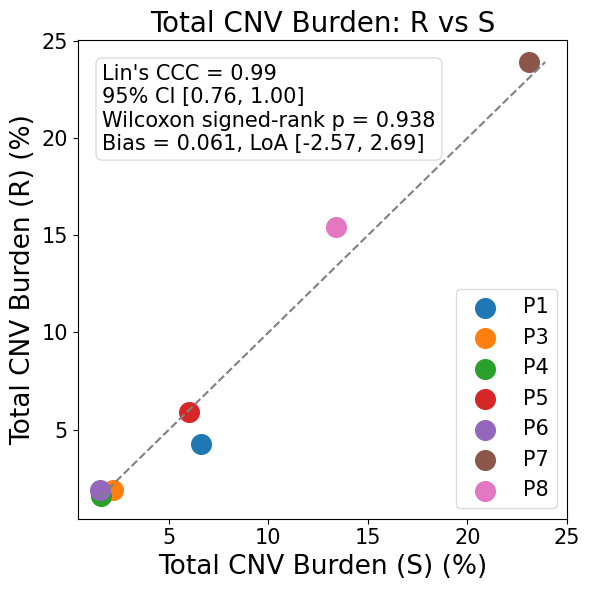

---


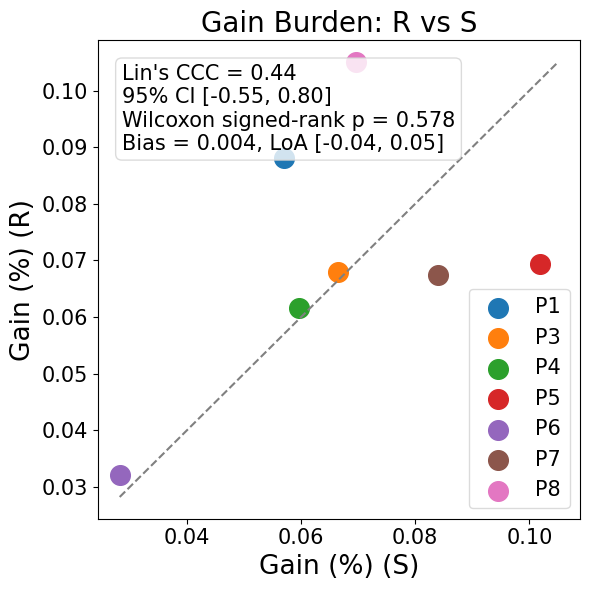

---


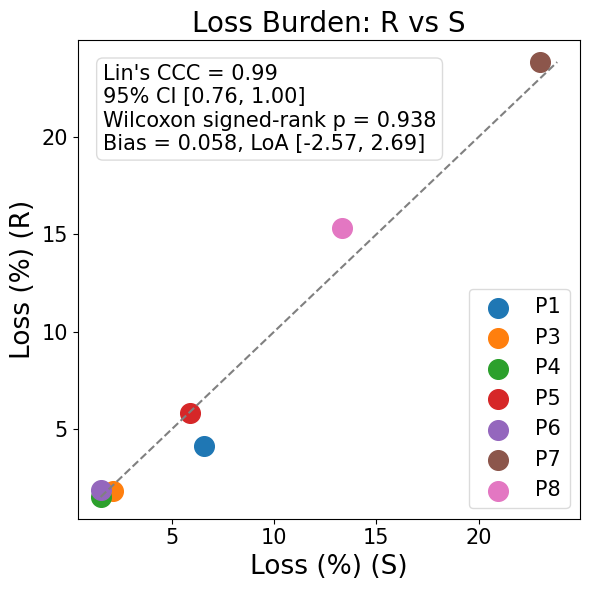

In [82]:
# plot_total_cnv_change(df_sr, save_path=f"{PLOTSAVEDIR}total_cnv_ci")
plot_total_cnv_change(df_sr, show_ccc=True, save_path=f"{PLOTSAVEDIR}total_cnv_ccc_ci", show_paired=True)

print("---")
# plot_sr_gain(df_sr, save_path=f"{PLOTSAVEDIR}cnv_gain_ci")
plot_sr_gain(df_sr, show_ccc=True, save_path=f"{PLOTSAVEDIR}cnv_gain_ccc_ci", show_paired=True)
print("---")
# plot_sr_loss(df_sr, save_path=f"{PLOTSAVEDIR}cnv_loss_ci")
plot_sr_loss(df_sr, show_ccc=True, save_path=f"{PLOTSAVEDIR}cnv_loss_ccc_ci", show_paired=True)

### Driver panel

Save results for `driver_concordance.py`

In [56]:
clairsto_all.to_pickle("clairsto_all.pkl")